In [1]:
import nn_fncs
import numpy as np

trajectory_samples = 400

def create_dataset_from_mat(file_path, list_of_vars):
    ws_files = nn_fncs.find_mat_files(file_path, recursive=True)
    input = np.zeros((trajectory_samples, 25))    
    for f in ws_files:
        print(f)
        mat_data = nn_fncs.read_mat_workspace(f)
        # N = mat_data.get('N')
        N = 2000
        if N is None:
            continue
        data = np.zeros((int(N), 1))
        skip = False
        for var in list_of_vars:
            temp_data = mat_data.get(var)
            if temp_data is not None:
                if np.isnan(temp_data).any():
                    skip = True
                    print(f"Skipping {f} due to NaN values in {var}")
                    break
                print(f"{var} found with shape {temp_data.shape}")
                data = np.hstack((data, temp_data))
            else:
                print(f"{var} not found in {f}, skipping this file.")
                skip = True
                break
        if skip: 
            continue
        data = data[::5, 1:]  # Remove the initial zero column
        input = np.dstack((input, data))

    print(input.shape)
    return input[1:]

In [2]:
data_labels = ['xout','Tail_Forces_out', 'Moments_Add_out']
data = create_dataset_from_mat('./Data', data_labels)
print(data.shape)
x_data = data[:, :12, :]
u_data = data[:, 12:, :]


C:\Users\brend\OneDrive - University of Glasgow\Dissertation\Main Fish Original\Main Fish Original\PyTorch_NN\RigidBody\Data\RigidBodyData_1.mat
xout found with shape (2000, 12)
Tail_Forces_out found with shape (2000, 12)
Moments_Add_out found with shape (2000, 1)
C:\Users\brend\OneDrive - University of Glasgow\Dissertation\Main Fish Original\Main Fish Original\PyTorch_NN\RigidBody\Data\RigidBodyData_10.mat
xout found with shape (2000, 12)
Tail_Forces_out found with shape (2000, 12)
Moments_Add_out found with shape (2000, 1)
C:\Users\brend\OneDrive - University of Glasgow\Dissertation\Main Fish Original\Main Fish Original\PyTorch_NN\RigidBody\Data\RigidBodyData_100.mat
xout found with shape (2000, 12)
Tail_Forces_out found with shape (2000, 12)
Moments_Add_out found with shape (2000, 1)
C:\Users\brend\OneDrive - University of Glasgow\Dissertation\Main Fish Original\Main Fish Original\PyTorch_NN\RigidBody\Data\RigidBodyData_1000.mat
xout found with shape (2000, 12)
Tail_Forces_out found

In [3]:

print(x_data.shape)
print(u_data.shape)
u_data = u_data[:, ~np.all(u_data == 0, axis=(0, 2)), :]
print(u_data.shape)

(399, 12, 3989)
(399, 13, 3989)
(399, 8, 3989)


In [4]:
# Randomly shuffle and split the dataset into training and testing sets
# Use a seed for reproducibility
np.random.seed(42)
num_trajectories = x_data.shape[2]
indices = np.random.permutation(num_trajectories)

x_data = x_data[:, :, indices]
u_data = u_data[:, :, indices]

In [5]:
import torch
from torch.utils.data import DataLoader
torch.set_default_dtype(torch.float32)

# Split data into training and validation sets
x_train_dataset = x_data[:,:,:-2]
x_valid_dataset = x_data[:,:,-2]
x_test_dataset = x_data[:,:,-1]

u_train_dataset = u_data[:,:,:-2]
u_valid_dataset = u_data[:,:,-2]
u_test_dataset = u_data[:,:,-1]

print('Train, Valid, Test dataset shapes:')
print(x_train_dataset.shape, x_valid_dataset.shape, x_test_dataset.shape)
print('Data Types:')
print(x_train_dataset.dtype, x_valid_dataset.dtype, x_test_dataset.dtype)

Train, Valid, Test dataset shapes:
(399, 12, 3987) (399, 12) (399, 12)
Data Types:
float64 float64 float64


In [6]:
# # Standardize the data

import torch
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
u_scaler = StandardScaler()

x_train_dataset = x_scaler.fit_transform(x_train_dataset.reshape(-1, x_train_dataset.shape[1])).reshape(x_train_dataset.shape)
u_train_dataset = u_scaler.fit_transform(u_train_dataset.reshape(-1, u_train_dataset.shape[1])).reshape(u_train_dataset.shape)

x_valid_dataset = x_scaler.transform(x_valid_dataset)
u_valid_dataset = u_scaler.transform(u_valid_dataset)

x_test_dataset = x_scaler.transform(x_test_dataset)
u_test_dataset = u_scaler.transform(u_test_dataset)


In [7]:
# Save scalers
import joblib
joblib.dump(x_scaler, 'x_scaler_clean.save')
joblib.dump(u_scaler, 'u_scaler_clean.save')

['u_scaler_clean.save']

In [8]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 64
dropout_rate = 0.1
class RigidBodyNN(nn.Module):
    def __init__(self, u_size=1, x_size=3, n_neurons=64):  
        super(RigidBodyNN, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.outputB(outB)

        x = outA + outB  
        return x

# Create the model
model = RigidBodyNN(u_size=u_train_dataset.shape[1], x_size=x_train_dataset.shape[1])

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')


RigidBodyNN(
  (A1): Linear(in_features=12, out_features=64, bias=True)
  (A2): Linear(in_features=64, out_features=64, bias=True)
  (A3): Linear(in_features=64, out_features=64, bias=True)
  (A4): Linear(in_features=64, out_features=64, bias=True)
  (outputA): Linear(in_features=64, out_features=12, bias=True)
  (B1): Linear(in_features=8, out_features=64, bias=True)
  (B2): Linear(in_features=64, out_features=64, bias=True)
  (outputB): Linear(in_features=64, out_features=12, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 19608


In [9]:
# Runge-Kutta 4th order method for ODE solving
def rk4_step_func(func, x0, u, dt):
    k1 = func(x0, u)
    k1 = k1*dt

    k2 = func(x0+k1/2, u)
    k2 = k2*dt

    k3 = func(x0+k2/2, u)
    k3 = k3*dt

    k4 = func(x0+k3, u)
    k4 = k4*dt

    return x0 + (k1 + 2 * (k2 + k3) + k4) / 6

In [10]:
# One step training
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_training_rk4(model, criterion, optimizer, x, u, dt):
    t = 0
    loss = 0.0
    model.train()
    with torch.set_grad_enabled(True):
        # Forward pass
        pred = rk4_step_func(model, x[:-1], u[:-1], dt)  # Integrate over a small time step
        loss = criterion(pred, x[1:])
        # Backward and optimize
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    r2 = r2_score(pred, x[1:])
    return pred, loss, r2

In [11]:
# Load trained model weights
model.load_state_dict(torch.load('./rigid_body_nn_model_clean_input.pth'))

<All keys matched successfully>

In [12]:
from random import randint
from tqdm import tqdm 
# Complete training loop
dt = 5e-3
num_epochs = 250
update_epochs = 1
mini_trajectory_length = 100
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
u_tensor = torch.from_numpy(u_train_dataset).type(torch.float32).to(device)
x_tensor = torch.from_numpy(x_train_dataset).type(torch.float32).to(device)
with tqdm(total=num_epochs, desc="Training Progress") as pbar:
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_r2 = 0.0
        for id in range(u_train_dataset.shape[2]):
            u_traj = u_tensor[:,:,id]
            x_traj = x_tensor[:,:,id]
            for start in range(0, u_traj.shape[0]-mini_trajectory_length, mini_trajectory_length):
                end = start + mini_trajectory_length
                u_traj_segment = u_traj[start:end]
                x_traj_segment = x_traj[start:end]
                pred, loss, r2 = one_step_training_rk4(model, criterion, optimizer, 
                                                       x_traj_segment, u_traj_segment, dt)
                epoch_loss += loss.item()*mini_trajectory_length
                epoch_r2 += r2.item()*mini_trajectory_length

        epoch_loss /= (u_tensor.shape[0]*u_tensor.shape[1])
        epoch_r2 /= (u_tensor.shape[0]*u_tensor.shape[1])
        if (epoch+1) % update_epochs == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6e}, R2: {epoch_r2:.6e}')
            pbar.update(update_epochs)

Training Progress:   0%|          | 1/250 [02:19<9:39:48, 139.71s/it]

Epoch [1/250], Loss: 3.860388e-05, R2: -inf


Training Progress:   1%|          | 2/250 [04:40<9:41:01, 140.57s/it]

Epoch [2/250], Loss: 3.823887e-05, R2: -inf


Training Progress:   1%|          | 2/250 [06:17<12:59:37, 188.62s/it]


KeyboardInterrupt: 

In [ ]:
# Save the trained model
torch.save(model.state_dict(), './rigid_body_nn_model_clean_input.pth')

Test R2: -INF -- MSE: 1.12403E-06 


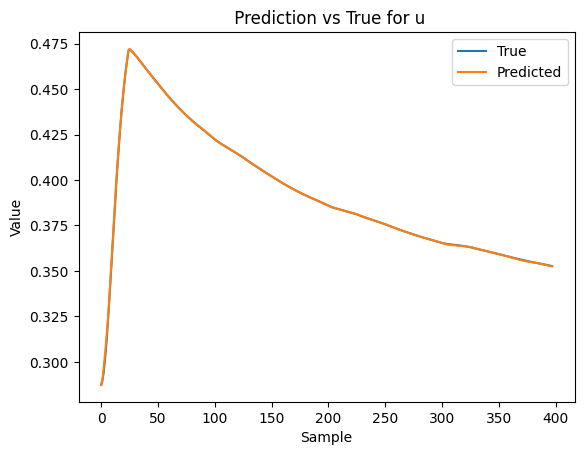

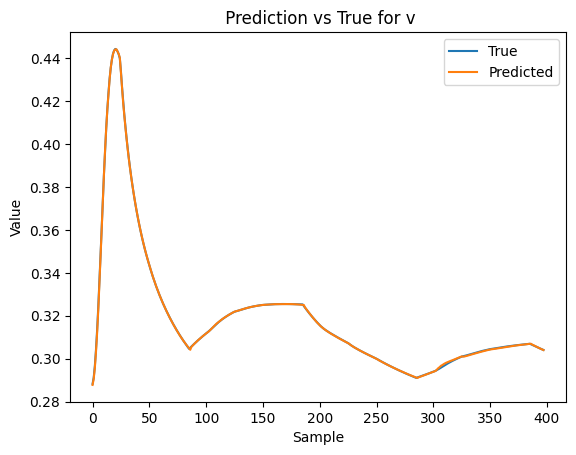

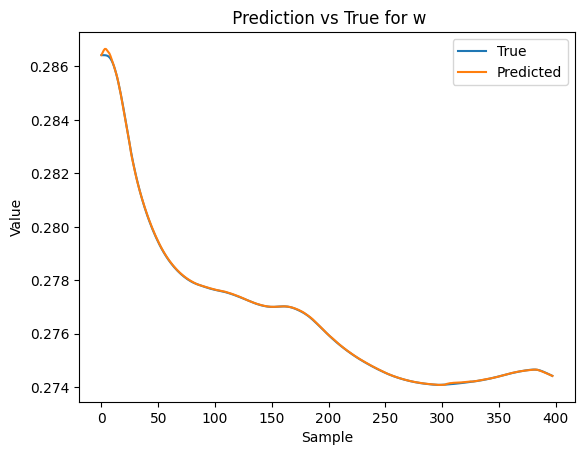

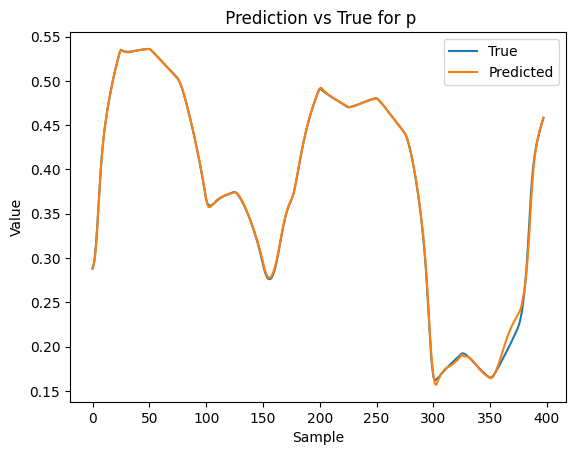

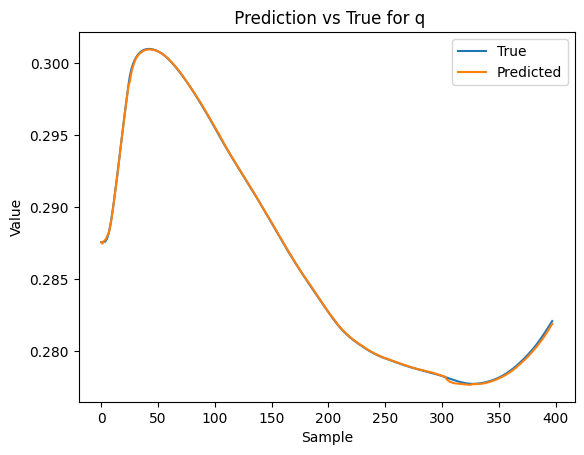

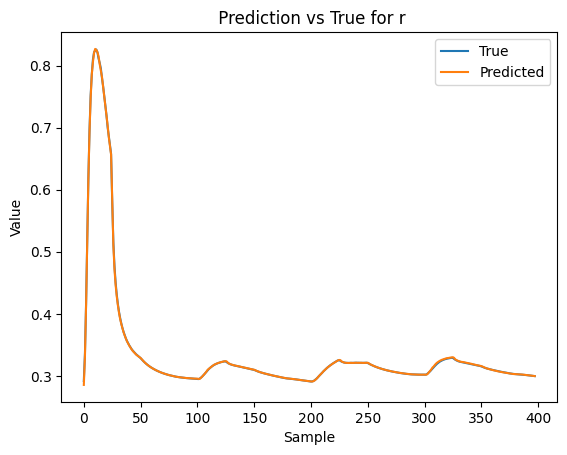

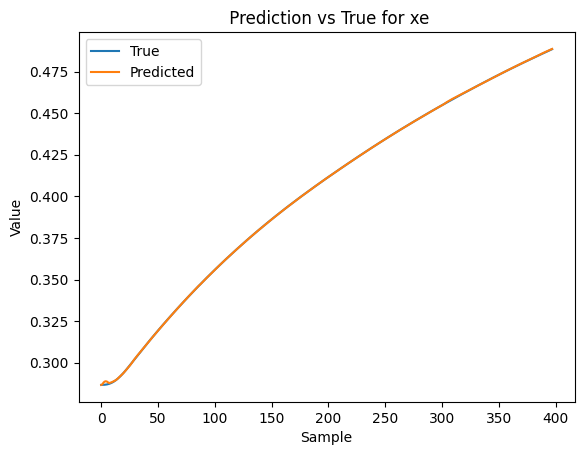

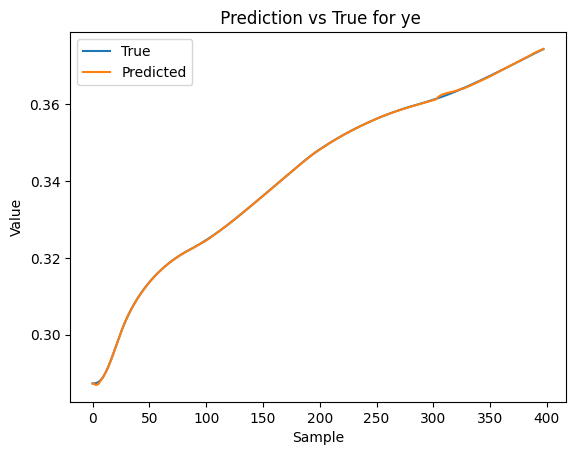

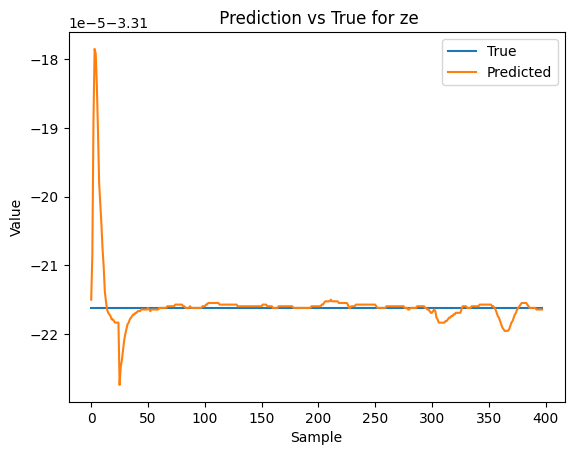

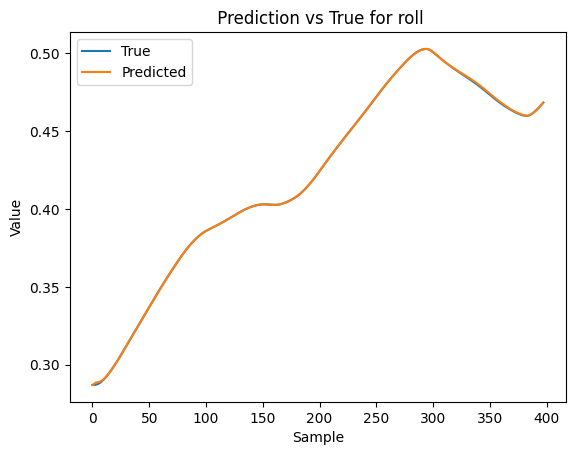

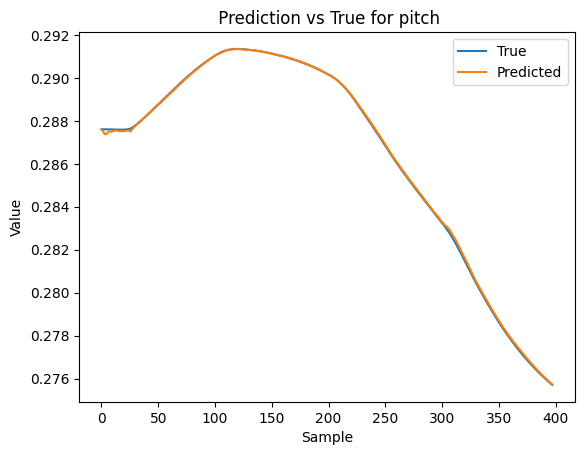

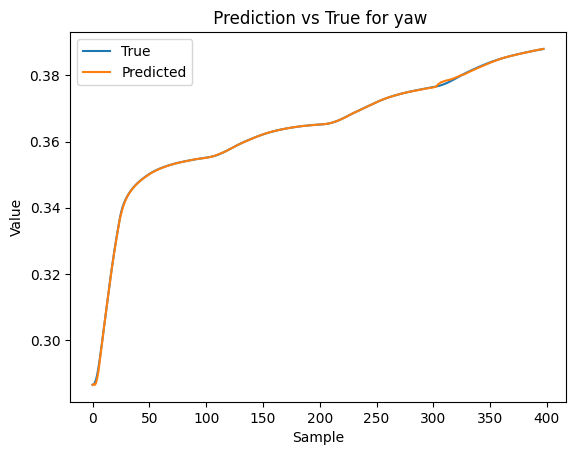

In [ ]:
# TESTING
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
import matplotlib.pyplot as plt

x_labels = ['u', 'v', 'w', 'p', 'q', 'r', 'xe', 'ye', 'ze', 'roll', 'pitch', 'yaw']
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

x_test_tensor = torch.from_numpy(x_test_dataset).type(torch.float32).to(device)
u_test_tensor = torch.from_numpy(u_test_dataset).type(torch.float32).to(device)

model.eval()
with torch.no_grad():
    x_pred = rk4_step_func(model, x_test_tensor[:-1], u_test_tensor[:-1], dt)
r2 = r2_score(x_pred,x_test_tensor[1:]) 
mse = mean_squared_error(x_pred, x_test_tensor[1:])
print(f"Test R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
for i in range(x_test_tensor.shape[1]):
    # plt.figure()
    # plt.plot(delta_x[:, i].cpu().detach().numpy(), label='delta_x')
    # plt.title(f' Delta x for variable {x_labels[i]}')
    # plt.xlabel('Sample')
    # plt.ylabel('Value')
    # plt.legend()
    # plt.show()
    
    plt.figure()
    plt.plot(x_test_tensor[1:, i].cpu().detach().numpy(), label='True')
    plt.plot(x_pred[:, i].cpu().detach().numpy(), label='Predicted')
    plt.title(f' Prediction vs True for {x_labels[i]}')
    plt.xlabel('Sample')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# Simulation

sim_size = x_test_tensor.shape[0]
input_sim = x_test_tensor[0, :]
#x_sim_history = np.zeros((test_dataset_input.shape[0],12))
x_sim_history = np.zeros((sim_size,12))
print( input_sim)
print(input_sim.shape)
print(x_test_tensor.shape)

#for i in range(test_dataset_output.shape[0]-1):
for i in range(sim_size-1):
    x_sim = rk4_step_func(model, input_sim, 
                             u_test_tensor[i, :], dt)
    input_sim = x_sim
    x_sim_history[i] = x_sim.cpu().detach().numpy()
print(x_sim_history.shape)

tensor([ 0.2870,  0.2879,  0.2864,  0.2869,  0.2876,  0.2859,  0.2867,  0.2873,
        -3.3102,  0.2870,  0.2876,  0.2865], device='cuda:0')
torch.Size([12])
torch.Size([399, 12])
(399, 12)


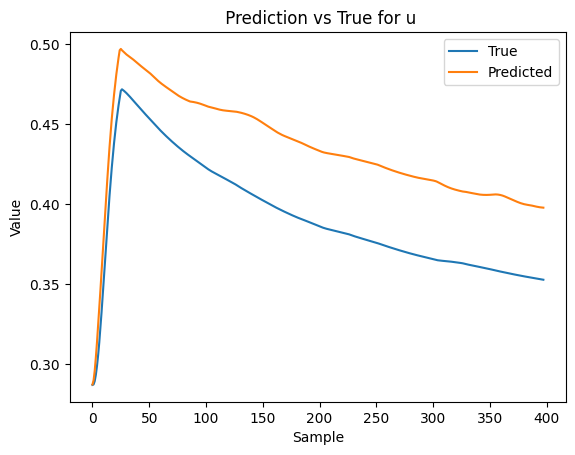

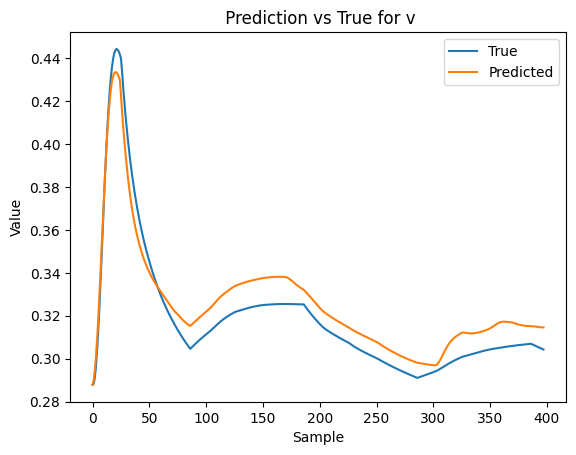

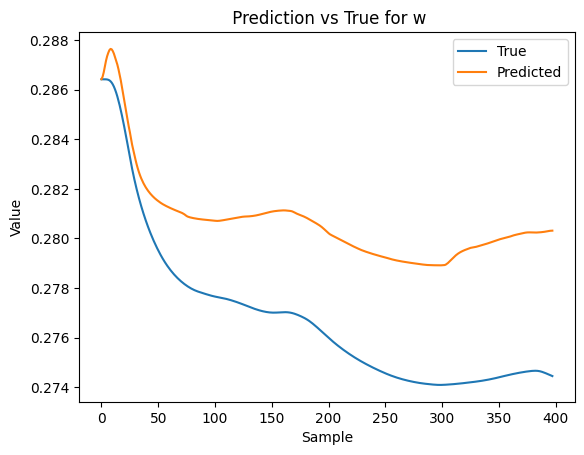

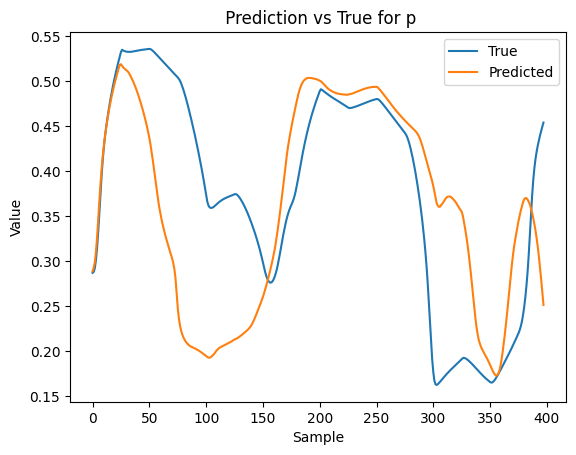

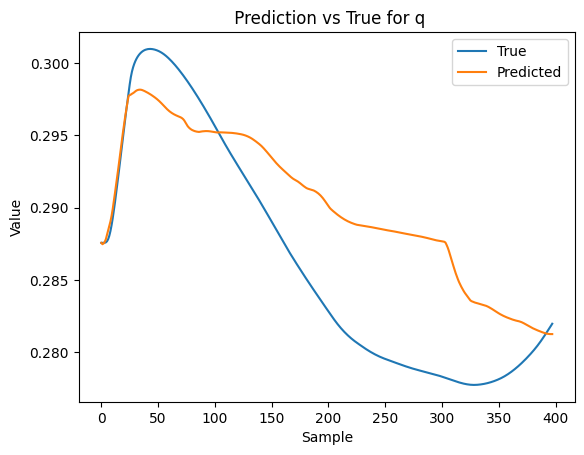

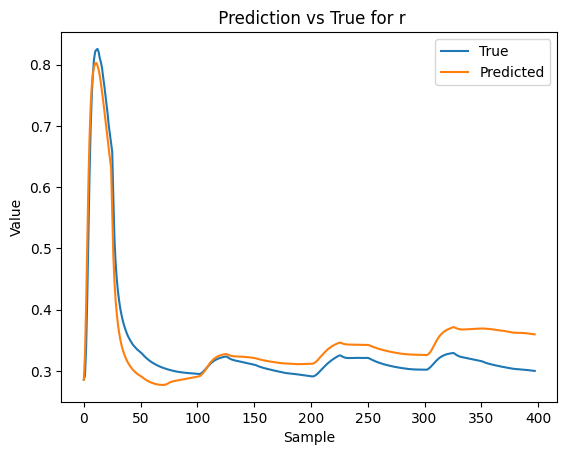

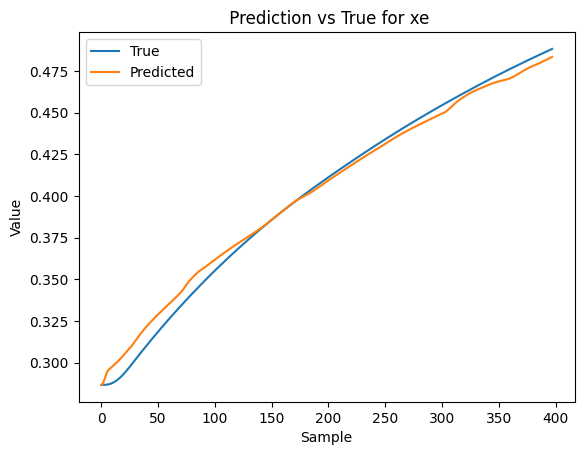

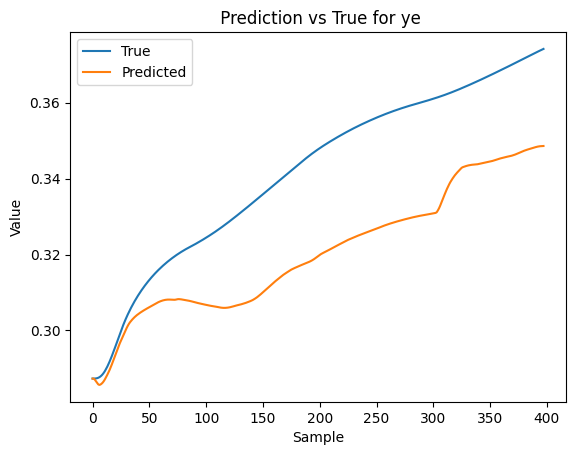

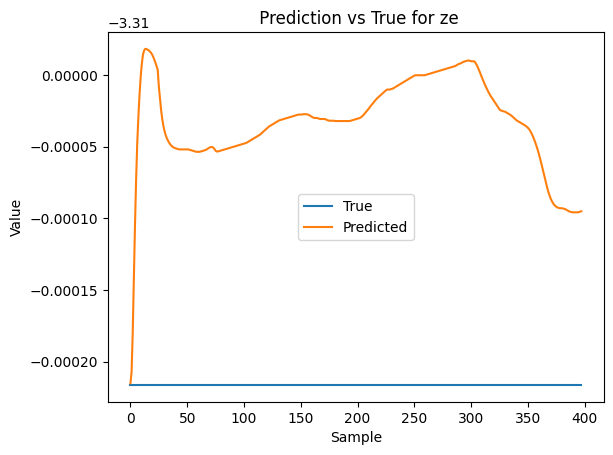

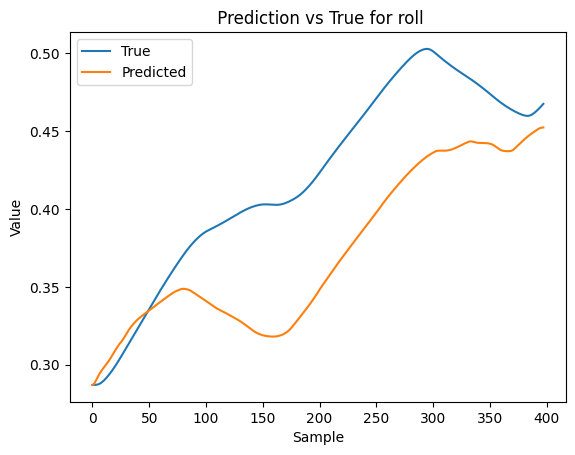

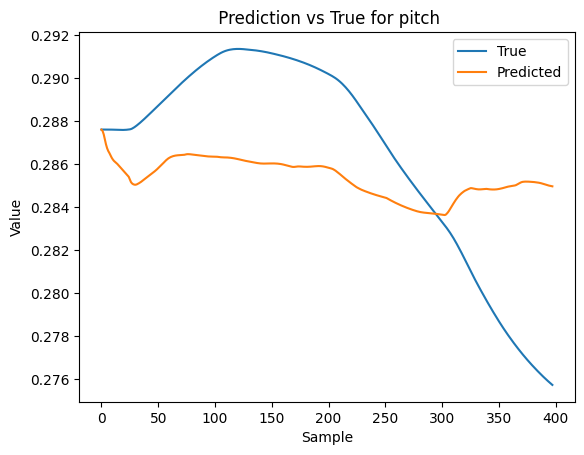

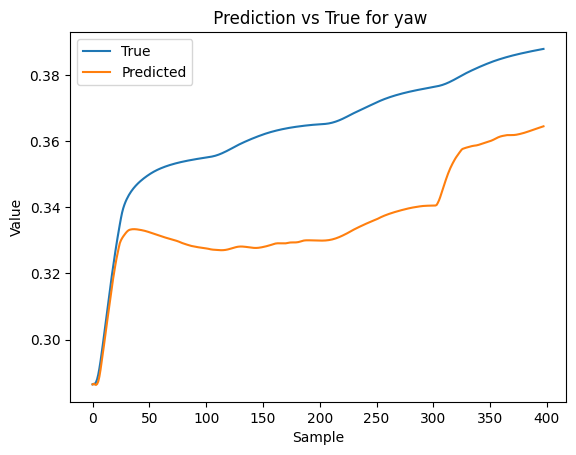

In [ ]:

for i in range(x_test_tensor.shape[1]):
    plt.figure()
    plt.plot(x_test_tensor[:-1, i].cpu().detach().numpy(), label='True')
    plt.plot(x_sim_history[:-1, i], label='Predicted')
    plt.title(f' Prediction vs True for {x_labels[i]}')
    plt.xlabel('Sample')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 32
dropout_rate = 0.5
class RigidBodyNNv2(nn.Module):
    def __init__(self, u_size=1, x_size=3):  
        super(RigidBodyNNv2, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.B3 = nn.Linear(n_neurons, n_neurons)
        self.B4 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.dropout(F.softplus(self.B3(outB)))
        outB = self.dropout(F.softplus(self.B4(outB)))
        outB = self.outputB(outB)

        x = outA + outB  
        return x

# Create the model
model = RigidBodyNNv2(u_size=u_train_dataset.shape[1], x_size=x_train_dataset.shape[1])

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')


RigidBodyNNv2(
  (A1): Linear(in_features=12, out_features=32, bias=True)
  (A2): Linear(in_features=32, out_features=32, bias=True)
  (A3): Linear(in_features=32, out_features=32, bias=True)
  (A4): Linear(in_features=32, out_features=32, bias=True)
  (outputA): Linear(in_features=32, out_features=12, bias=True)
  (B1): Linear(in_features=8, out_features=32, bias=True)
  (B2): Linear(in_features=32, out_features=32, bias=True)
  (B3): Linear(in_features=32, out_features=32, bias=True)
  (B4): Linear(in_features=32, out_features=32, bias=True)
  (outputB): Linear(in_features=32, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Total parameters: 7832


In [ ]:
# load the trained model weights
model.load_state_dict(torch.load('./rigid_body_nn_model_v2_clean.pth'))

<All keys matched successfully>

In [ ]:
from random import randint
from tqdm import tqdm 
# Complete training loop
dt = 5e-3
num_epochs = 10
mini_trajectory_length = 100
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-3)
u_tensor = torch.from_numpy(u_train_dataset).type(torch.float32).to(device)
x_tensor = torch.from_numpy(x_train_dataset).type(torch.float32).to(device)
with tqdm(total=num_epochs, desc="Training Progress") as pbar:
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_r2 = 0.0
        for id in range(u_train_dataset.shape[2]):
            u_traj = u_tensor[:,:,id]
            x_traj = x_tensor[:,:,id]
            for start in range(0, u_traj.shape[0]-mini_trajectory_length, mini_trajectory_length):
                end = start + mini_trajectory_length
                u_traj_segment = u_traj[start:end]
                x_traj_segment = x_traj[start:end]
                pred, loss, r2 = one_step_training_rk4(model, criterion, optimizer, 
                                                       x_traj_segment, u_traj_segment, dt)
                epoch_loss += loss.item()*mini_trajectory_length
                epoch_r2 += r2.item()*mini_trajectory_length

        epoch_loss /= (u_tensor.shape[0]*u_tensor.shape[1])
        epoch_r2 /= (u_tensor.shape[0]*u_tensor.shape[1])

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6e}, R2: {epoch_r2:.6e}')
        pbar.update(1)

Training Progress:  10%|█         | 1/10 [02:39<23:57, 159.67s/it]

Epoch [1/10], Loss: 8.787845e-04, R2: -inf


Training Progress:  20%|██        | 2/10 [05:16<21:04, 158.12s/it]

Epoch [2/10], Loss: 8.739117e-04, R2: -inf


Training Progress:  30%|███       | 3/10 [07:53<18:24, 157.73s/it]

...

Epoch [8/10], Loss: 8.379361e-04, R2: -inf


Training Progress:  90%|█████████ | 9/10 [23:22<02:35, 155.02s/it]

Epoch [9/10], Loss: 8.342299e-04, R2: -inf


Training Progress: 100%|██████████| 10/10 [25:59<00:00, 156.00s/it]

Epoch [10/10], Loss: 8.298726e-04, R2: -inf


In [ ]:
# Print model type
print(type(model))

<class '__main__.RigidBodyNNv2'>


In [ ]:
# Simulation

sim_size = x_test_tensor.shape[0]
input_sim = x_test_tensor[0, :]
#x_sim_history = np.zeros((test_dataset_input.shape[0],12))
x_sim_history = np.zeros((sim_size,12))
print( input_sim)
print(input_sim.shape)
print(x_test_tensor.shape)

model.eval()
with torch.no_grad():
    #for i in range(test_dataset_output.shape[0]-1):
    for i in range(sim_size-1):
        x_sim = rk4_step_func(model, input_sim, 
                                u_test_tensor[i, :], dt)
        input_sim = x_sim
        x_sim_history[i] = x_sim.cpu().detach().numpy()
    print(x_sim_history.shape)

tensor([ 0.2870,  0.2879,  0.2864,  0.2869,  0.2876,  0.2859,  0.2867,  0.2873,
        -3.3102,  0.2870,  0.2876,  0.2865], device='cuda:0')
torch.Size([12])
torch.Size([399, 12])
(399, 12)


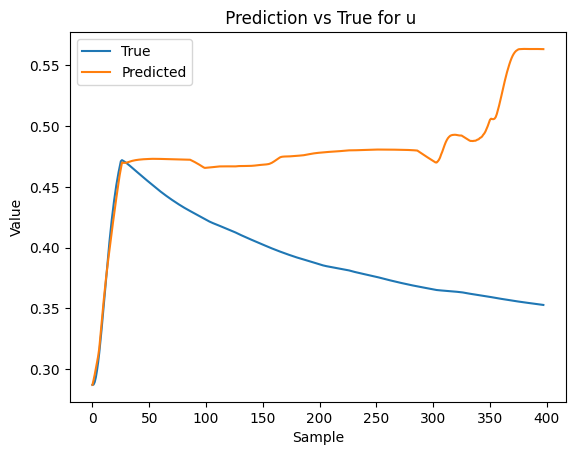

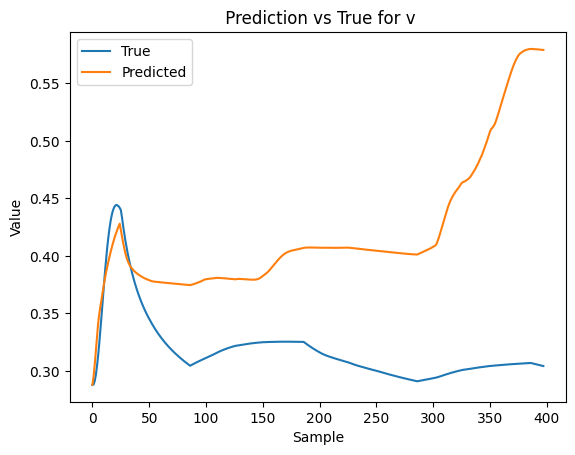

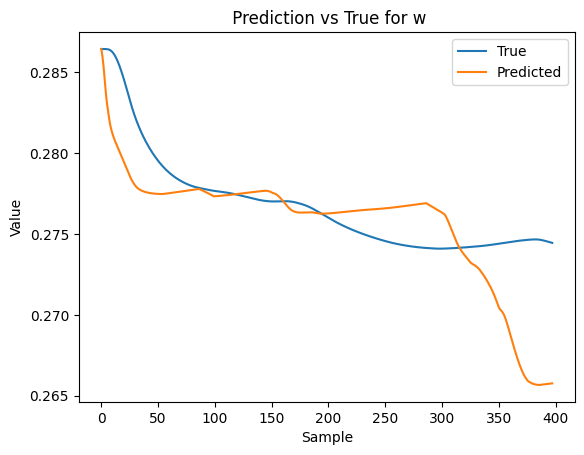

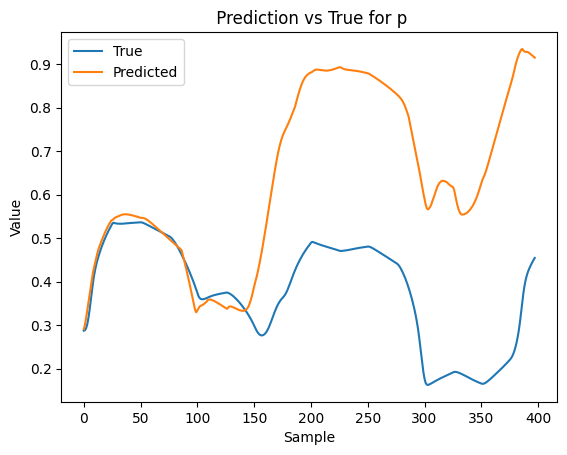

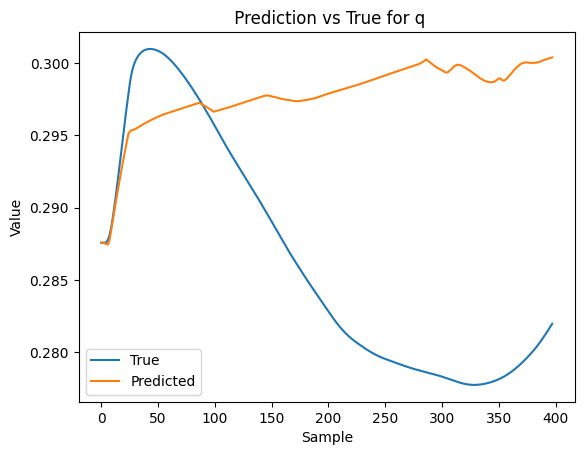

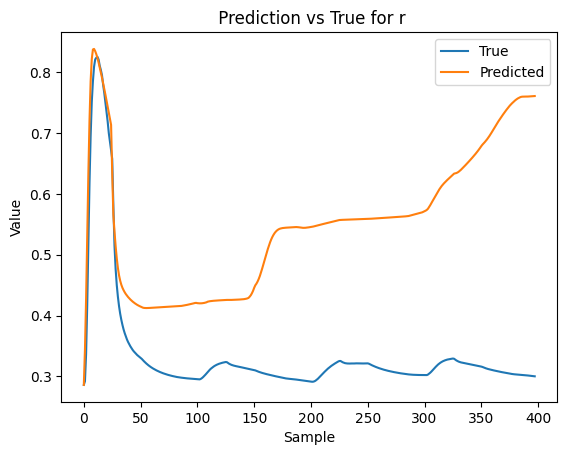

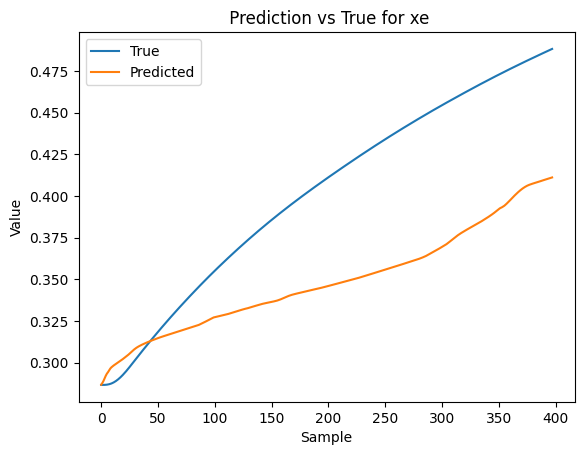

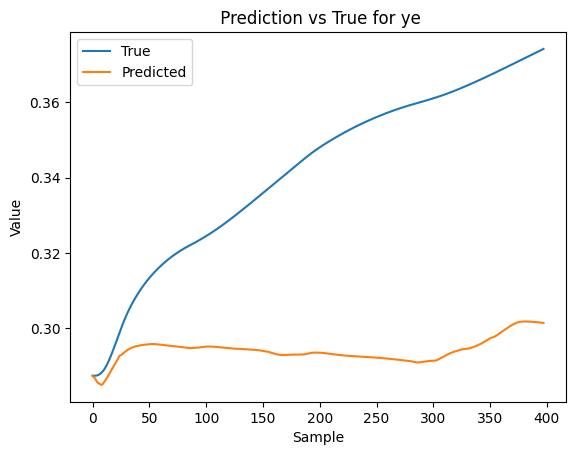

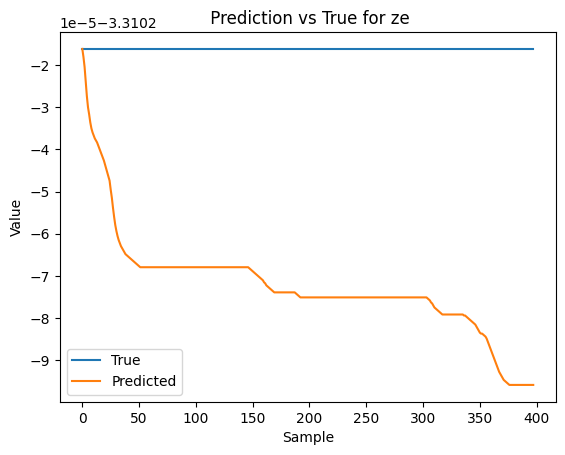

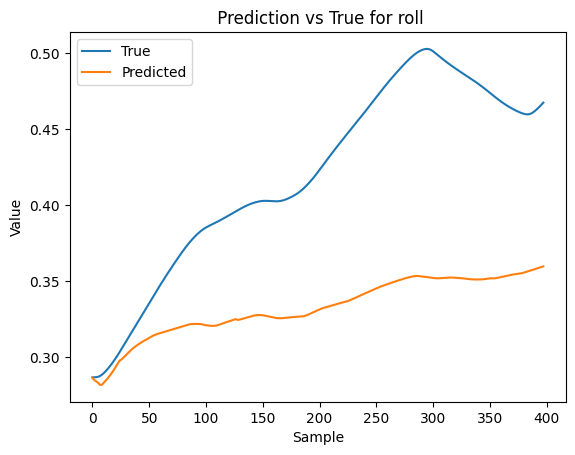

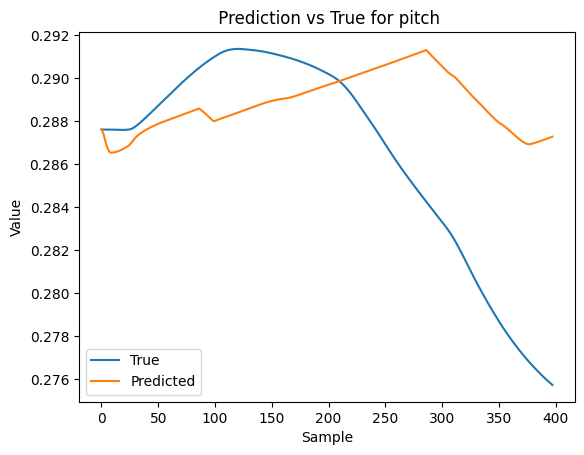

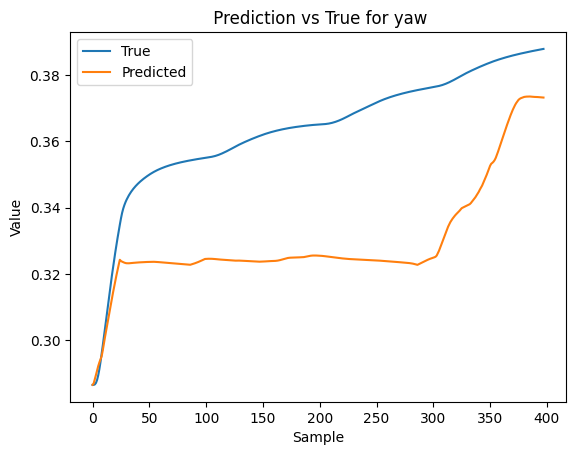

In [ ]:
for i in range(x_test_tensor.shape[1]):
    plt.figure()
    plt.plot(x_test_tensor[:-1, i].cpu().detach().numpy(), label='True')
    plt.plot(x_sim_history[:-1, i], label='Predicted')
    plt.title(f' Prediction vs True for {x_labels[i]}')
    plt.xlabel('Sample')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# save the trained model
torch.save(model.state_dict(), 'rigid_body_nn_model_v2_clean.pth')

In [13]:
# Compare three models
model1 = RigidBodyNN(u_size=u_train_dataset.shape[1], x_size=x_train_dataset.shape[1], n_neurons=64).to(device)
model2 = RigidBodyNNv2(u_size=u_train_dataset.shape[1], x_size=x_train_dataset.shape[1]).to(device)
model3 = RigidBodyNN(u_size=u_train_dataset.shape[1], x_size=x_train_dataset.shape[1], n_neurons=64).to(device)
#  Load trained model weights
model1.load_state_dict(torch.load('./rigid_body_nn_model_clean_input.pth'))
model2.load_state_dict(torch.load('./rigid_body_nn_model_v2_clean.pth'))
model3.load_state_dict(torch.load('./rigid_body_nn_model_clean_input_1.pth'))

# Simulation


NameError: name 'RigidBodyNNv2' is not defined

In [ ]:
# Simulation
from torcheval.metrics.functional import r2_score, mean_squared_error
def simulate_model(model, x_test_tensor, u_test_tensor, dt):
    model.eval()
    with torch.no_grad():
        sim_size = x_test_tensor.shape[0]
        input_sim = x_test_tensor[0, :]
        x_sim_history = torch.zeros((sim_size, 12),device=device)
        for i in range(sim_size - 1):
            x_sim = rk4_step_func(model, input_sim,
                                   u_test_tensor[i, :], dt)
            input_sim = x_sim
            x_sim_history[i] = x_sim
    mse = mean_squared_error(x_sim_history[:-1], x_test_tensor[:-1])
    r2 = r2_score(x_sim_history[:-1], x_test_tensor[:-1], multioutput='raw_values')
    # remove infinite values from r2
    r2 = r2[~torch.isinf(r2)].mean()
    print(f"Model: {model.__class__.__name__}, MSE: {mse:.4f}, R2: {r2}")
    return x_sim_history


In [ ]:
# Simulate and evaluate each model
dt = 5e-3
x_sim_history1 = simulate_model(model1, x_test_tensor, u_test_tensor, dt)
x_sim_history2 = simulate_model(model2, x_test_tensor, u_test_tensor, dt)
x_sim_history3 = simulate_model(model3, x_test_tensor, u_test_tensor, dt)



Model: RigidBodyNN, MSE: 0.0018, R2: 0.09285088628530502
Model: RigidBodyNNv2, MSE: 0.0180, R2: -4.095308780670166
Model: RigidBodyNN, MSE: 0.0030, R2: 0.29628419876098633


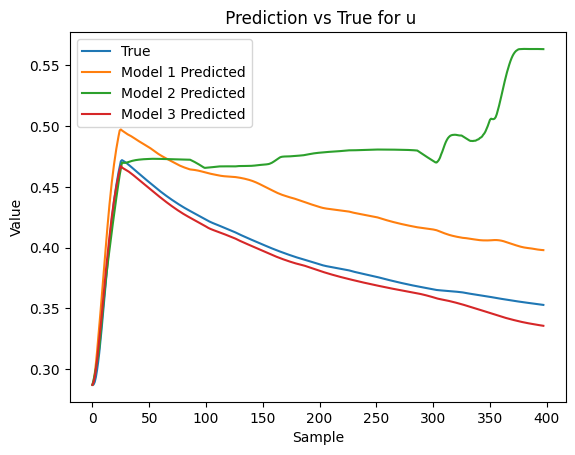

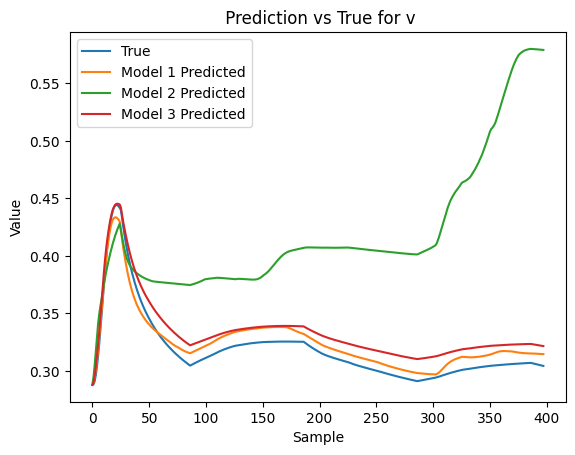

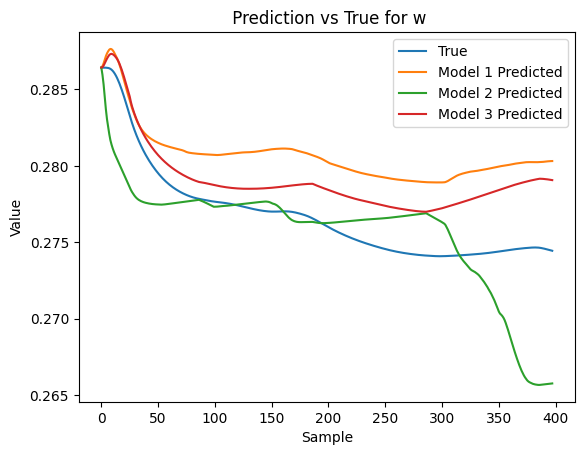

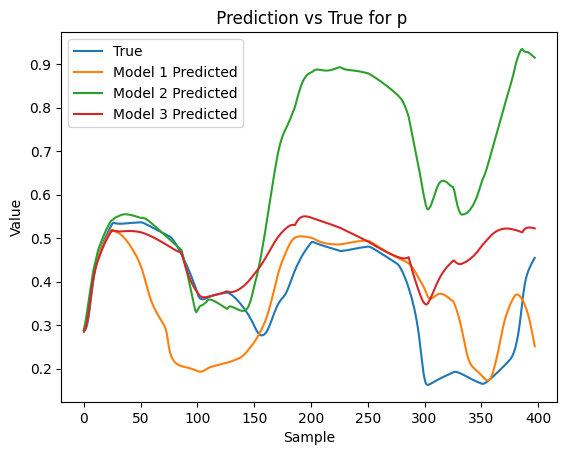

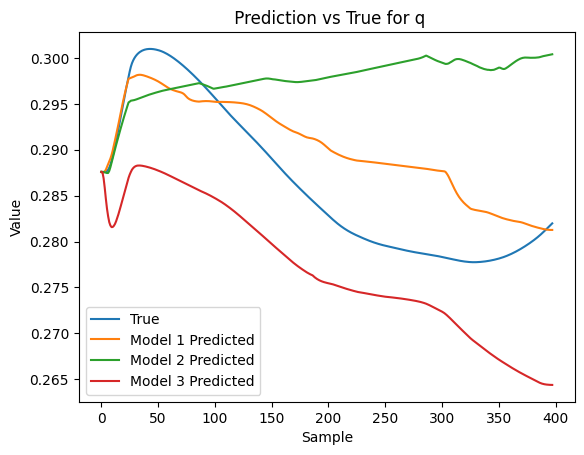

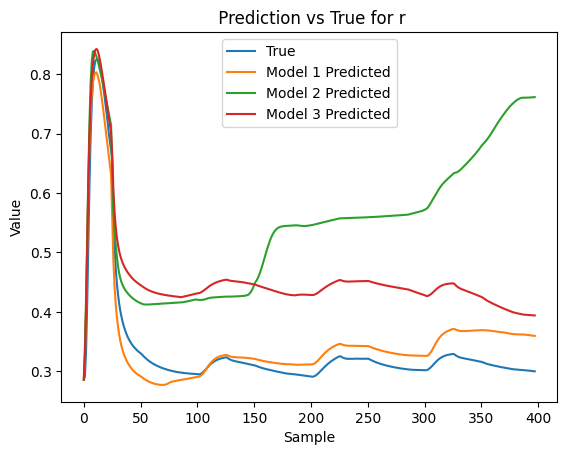

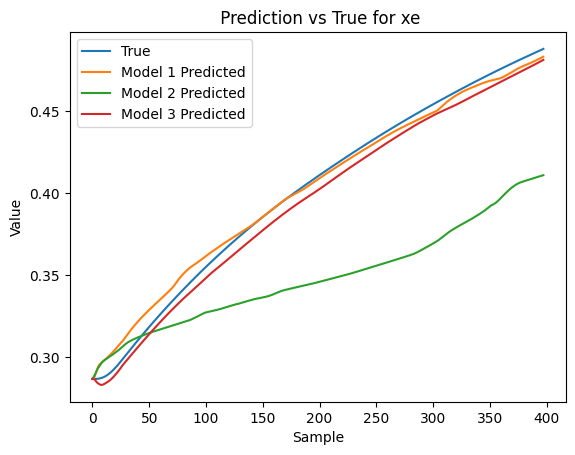

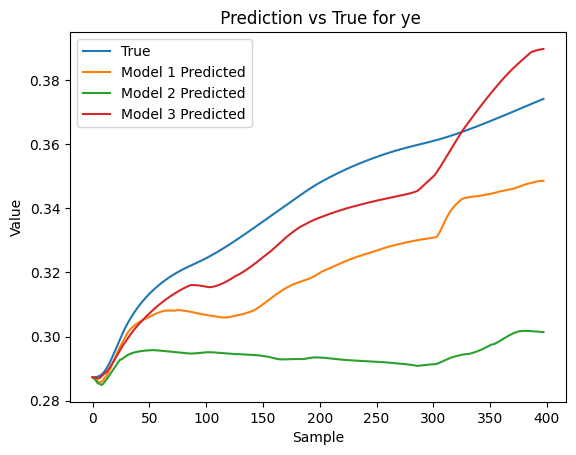

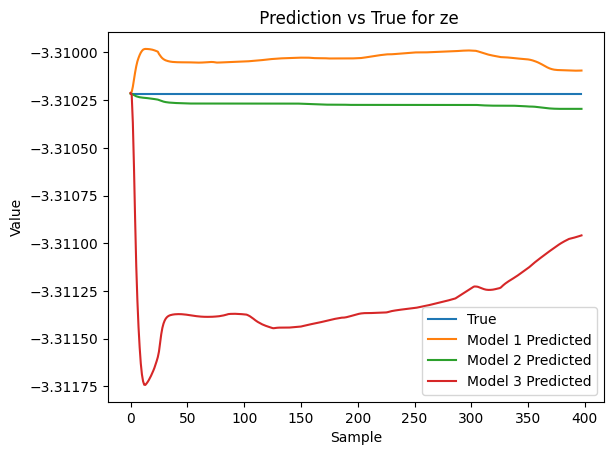

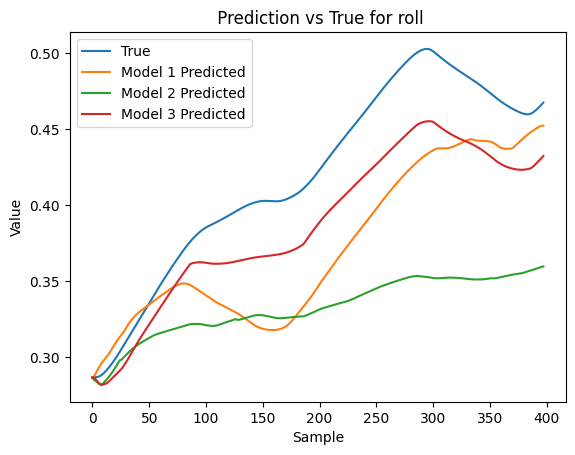

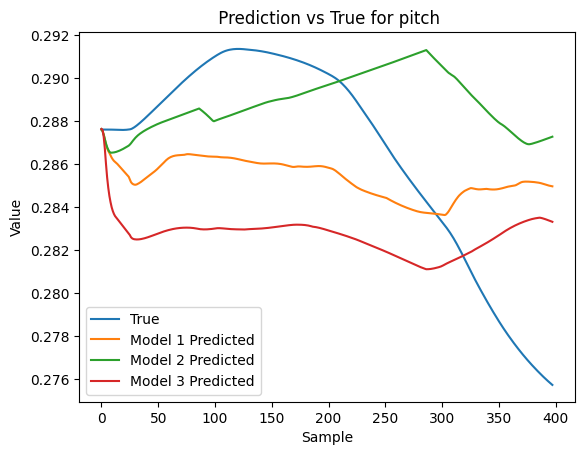

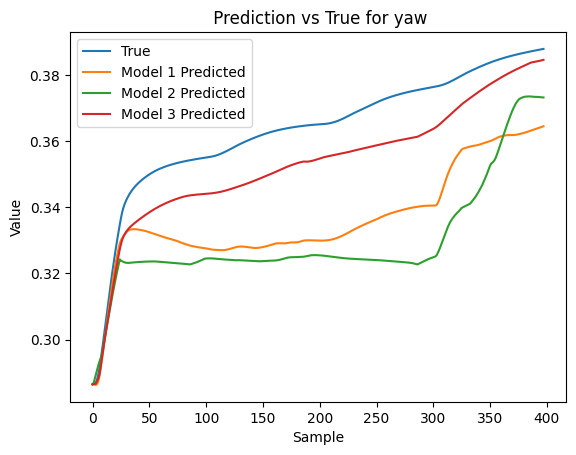

In [ ]:
# Compare predictions
for i in range(x_test_tensor.shape[1]):
    plt.subplot(3, 1, i+1)
    plt.figure()
    plt.plot(x_test_tensor[:-1, i].cpu().detach().numpy(), label='True')

    plt.plot(x_sim_history1[:-1, i].cpu().detach().numpy(), linestyle='--', label='Model 1 Predicted')
    plt.plot(x_sim_history2[:-1, i].cpu().detach().numpy(), linestyle='--', label='Model 2 Predicted')
    plt.plot(x_sim_history3[:-1, i].cpu().detach().numpy(), linestyle='--', label='Model 3 Predicted')
    plt.title(f' Prediction vs True for {x_labels[i]}')
    plt.xlabel('Sample')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# save the scalers
import joblib
joblib.dump(x_scaler, 'x_scaler.save')
joblib.dump(u_scaler, 'u_scaler.save')

['u_scaler.save']